In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

In [3]:
warnings.simplefilter("ignore")

In [10]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)
        
        # Sigmoid activation function for binary classification
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate through LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Pass the output of the last time step through the fully connected layer
        out = self.fc(out[:, -1, :])  # Extract the last time step output
        
        # Apply sigmoid activation to get probability
        return self.sigmoid(out)

# Dataset Class
class LightCurveDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Function to load magnitude column from a CSV file
def load_magnitudes(file_path, source_type):
    data = pd.read_csv(file_path)
    if source_type == "main_sequence":
        data = data.sort_values(by="JD (TCB)")
        #good_idx = np.where(data.iloc[:, 16] == 0)[0]
        #magnitudes = data.iloc[good_idx, 7]
        magnitudes = data["avg Mag"]
    elif source_type == "gaia":
        data = data.sort_values(by="JD (TCB)")
        magnitudes = data["avg Mag"]  
    elif source_type == "zenodo":
        data = data.sort_values(by="jds")
        magnitudes = data["mags"]
    elif source_type == "aavso":
        data = data.sort_values(by="JD")
        magnitudes = data["Magnitude"]
    else:
        raise ValueError(f"Unknown source type: {source_type}")
    
    # Ensure magnitudes are numeric and drop invalid values
    magnitudes = pd.to_numeric(magnitudes, errors='coerce').dropna()
    return magnitudes.values  # Return as a NumPy array

# Function to load data from the "main sequence" folder
def load_main_sequence_data(directory, label):
    data = []
    labels = []
    for n in range(1000):
        for file_name in os.listdir(directory):
            file_path = os.path.join(directory, file_name)
            if file_name.endswith('.csv'):
                magnitudes = load_magnitudes(file_path, source_type="main_sequence")
                data.append(torch.tensor(magnitudes, dtype=torch.float32).unsqueeze(1))
                labels.append(label)
    return data, labels

# Function to load data from the "rcb data" folder
def load_rcb_data(directory, label):
    data = []
    labels = []
    for subfolder_name in os.listdir(directory):
        subfolder_path = os.path.join(directory, subfolder_name)
        if os.path.isdir(subfolder_path):
            source_type = ""
            if "gaia" in subfolder_name.lower():
                source_type = "gaia"
            elif "zenodo" in subfolder_name.lower():
                source_type = "zenodo"
            elif "aavso" in subfolder_name.lower():
                source_type = "aavso"
            # source_type = "gaia" if "gaia" in subfolder_name.lower() else "zenodo"
            for file_name in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file_name)
                if file_name.endswith('.csv'):
                    magnitudes = load_magnitudes(file_path, source_type=source_type)
                    data.append(torch.tensor(magnitudes, dtype=torch.float32).unsqueeze(1))
                    labels.append(label)
    return data, labels

# Pad sequences to the same length
def pad_sequences(sequences, max_len):
    padded = torch.zeros((len(sequences), max_len, 1))  
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        padded[i, :length, 0] = seq[:length, 0]
    return padded

In [ ]:
# hyperparamters
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1
learning_rate = 0.001
epochs = 5
loss = 0
# Define model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_size, hidden_size, num_layers, output_size).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

checkpoint_path = 'checkpoint.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    loss = checkpoint['loss']
else:
    start_epoch = 0

# Initialize epoch to ensure it is defined outside the loop
epoch = start_epoch - 1  # Default to the last completed epoch before training starts
correct = 0

In [12]:
# Load data

main_sequence_dir = r'c:\Users\lboui\CORONA\caitlinbegbie CORONA melina gaia_mainseq'

rcb_data_dir = r'c:\Users\lboui\CORONA\rcb data'

# Load and preprocess data
main_sequence_data, main_sequence_labels = load_main_sequence_data(main_sequence_dir, label=0)
rcb_data, rcb_labels = load_rcb_data(rcb_data_dir, label=1)
print("lengths of main seq and rcb: ", len(main_sequence_data), len(rcb_data))
# Combine data and labels
data = main_sequence_data + rcb_data
labels = torch.tensor(main_sequence_labels + rcb_labels, dtype=torch.float32).unsqueeze(1)

# Pad sequences to the same length
max_len = max(len(seq) for seq in data)
data = pad_sequences(data, max_len)
print("max length:", max_len)
# Create dataset and dataloader
dataset = LightCurveDataset(data, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

lengths of main seq and rcb:  42000 2545
max length: 2213


In [20]:
print(42000/(42000+2545))

0.9428667639465709


In [16]:
# Train
losses = []
for epoch in range(start_epoch, epochs):
    for batch in dataloader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(x_batch)
        correct += len([1 for p in outputs - y_batch if p.item() < 0.2 and p.item() > -0.2])
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        if (epoch + 1) % 1 == 0:
            print(torch.cat((torch.cat((outputs, y_batch), dim=1), outputs - y_batch), dim=1))
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, % correct: {correct * 100 / 44468}')
        correct = 0

# Save checkpoint
torch.save({
    'epoch': epoch,  # Now 'epoch' is guaranteed to be defined
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, checkpoint_path)

# Prediction Example
def predict(model, sample):
    model.eval()
    sample = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(sample).item()
    return prob

# Example prediction on a new light curve sample
sample_curve = np.random.rand(max_len, input_size)
probability = predict(model, sample_curve)
print(f'Probability of being an RCB star: {probability:.4f}')

tensor([[0.0484, 0.0000, 0.0484]], device='cuda:0')
Epoch [1/30], Loss: 0.0496, % correct: 93.13438877394981
tensor([[0.0675, 0.0000, 0.0675]], device='cuda:0')
Epoch [2/30], Loss: 0.0699, % correct: 94.5151569668076
tensor([[0.0583, 0.0000, 0.0583]], device='cuda:0')
Epoch [3/30], Loss: 0.0600, % correct: 94.5151569668076
tensor([[0.0473, 0.0000, 0.0473]], device='cuda:0')
Epoch [4/30], Loss: 0.0484, % correct: 94.5151569668076
tensor([[0.0652, 0.0000, 0.0652]], device='cuda:0')
Epoch [5/30], Loss: 0.0674, % correct: 94.51065935054422
tensor([[0.0664, 0.0000, 0.0664]], device='cuda:0')
Epoch [6/30], Loss: 0.0687, % correct: 94.50616173428084
tensor([[0.0573, 0.0000, 0.0573]], device='cuda:0')
Epoch [7/30], Loss: 0.0590, % correct: 94.5151569668076
tensor([[0.0541, 0.0000, 0.0541]], device='cuda:0')
Epoch [8/30], Loss: 0.0557, % correct: 94.5151569668076
tensor([[0.0681, 0.0000, 0.0681]], device='cuda:0')
Epoch [9/30], Loss: 0.0706, % correct: 94.5151569668076
tensor([[0.0458, 0.0000, 

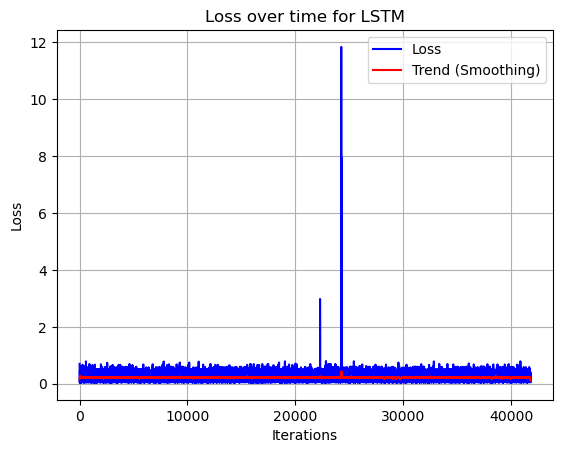

In [ ]:
updates = range(1, len(losses) + 1)
kernel = np.ones(100) * 1/100
smoothed = np.convolve(losses, kernel, mode="same")
plt.plot(updates, losses, color="blue", label="Loss")
plt.plot(updates, smoothed, color="red", label="Trend (Smoothing)")
plt.title("Loss over time for LSTM")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()